In [1]:
from pathlib import Path

base = Path("/kaggle/input/aerialimageryforroofsegmentation")

for split in ["train", "val", "test"]:
    imgs = list((base / split / "image").glob("*.tif"))
    masks = list((base / split / "label").glob("*.tif"))
    print(f"{split}: Images={len(imgs)}, Masks={len(masks)}")

train: Images=857, Masks=1714
val: Images=94, Masks=188
test: Images=95, Masks=190


In [2]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 49.8 MB/s eta 0:00:00


In [3]:
import rasterio
import pandas as pd

records = []

for split in ["train", "val", "test"]:
    for img_path in (base / split / "image").glob("*.tif"):
        with rasterio.open(img_path) as src:
            h, w = src.height, src.width
        records.append({
            "split": split,
            "width": w,
            "height": h,
            "aspect_ratio": w / h
        })

df = pd.DataFrame(records)
print(df.groupby("split")[["width", "height"]].describe())

       width                                                              \
       count          mean       std      min      25%      50%      75%   
split                                                                      
test    95.0  10000.000000    0.0000  10000.0  10000.0  10000.0  10000.0   
train  857.0   9991.070012  261.4215   2347.0  10000.0  10000.0  10000.0   
val     94.0  10000.000000    0.0000  10000.0  10000.0  10000.0  10000.0   

               height                                                       \
           max  count          mean         std      min      25%      50%   
split                                                                        
test   10000.0   95.0  10000.000000    0.000000  10000.0  10000.0  10000.0   
train  10000.0  857.0   9856.777130  978.386902   3181.0  10000.0  10000.0   
val    10000.0   94.0   9854.914894  989.291325   3181.0  10000.0  10000.0   

                         
           75%      max  
split                 

In [4]:
import rasterio
import pandas as pd

records = []

for split in ["train", "val", "test"]:
    for img_path in (base / split / "image").glob("*.tif"):
        with rasterio.open(img_path) as src:
            h, w = src.height, src.width
        records.append({
            "split": split,
            "width": w,
            "height": h,
            "aspect_ratio": w / h
        })

df = pd.DataFrame(records)
print(df.groupby("split")[["width", "height"]].describe())

       width                                                              \
       count          mean       std      min      25%      50%      75%   
split                                                                      
test    95.0  10000.000000    0.0000  10000.0  10000.0  10000.0  10000.0   
train  857.0   9991.070012  261.4215   2347.0  10000.0  10000.0  10000.0   
val     94.0  10000.000000    0.0000  10000.0  10000.0  10000.0  10000.0   

               height                                                       \
           max  count          mean         std      min      25%      50%   
split                                                                        
test   10000.0   95.0  10000.000000    0.000000  10000.0  10000.0  10000.0   
train  10000.0  857.0   9856.777130  978.386902   3181.0  10000.0  10000.0   
val    10000.0   94.0   9854.914894  989.291325   3181.0  10000.0  10000.0   

                         
           75%      max  
split                 

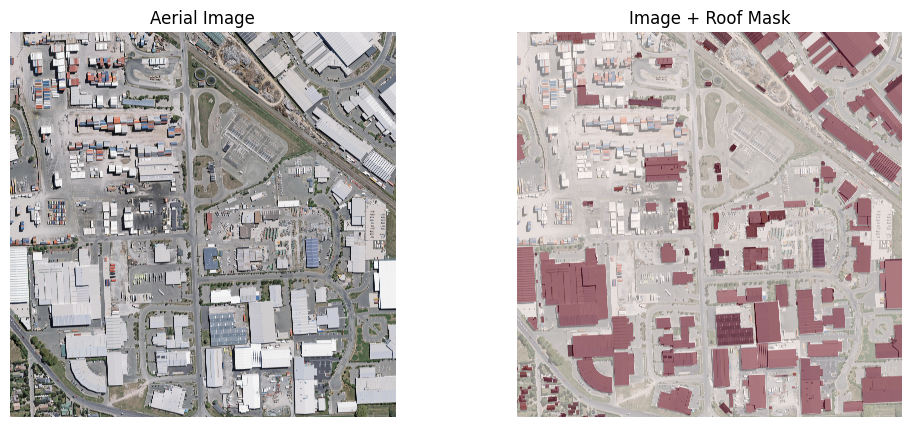

In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

img_path = random.choice(list((base/"train/image").glob("*.tif")))
mask_path = base/"train/label"/img_path.name

with rasterio.open(img_path) as img_src:
    img = img_src.read([1,2,3]).transpose(1,2,0)

with rasterio.open(mask_path) as mask_src:
    mask = mask_src.read(1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Aerial Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(mask, alpha=0.5, cmap="Reds")
plt.title("Image + Roof Mask")
plt.axis("off")

plt.show()


In [6]:
import numpy as np

def roof_ratio(mask):
    return np.sum(mask > 0) / mask.size

ratios = []

for mask_path in (base/"train/label").glob("*.tif"):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    ratios.append(roof_ratio(mask))

print(f"Avg roof coverage: {np.mean(ratios)*100:.2f}%")
print(f"Min: {np.min(ratios)*100:.2f}% | Max: {np.max(ratios)*100:.2f}%")


Avg roof coverage: 7.69%
Min: 0.00% | Max: 35.66%


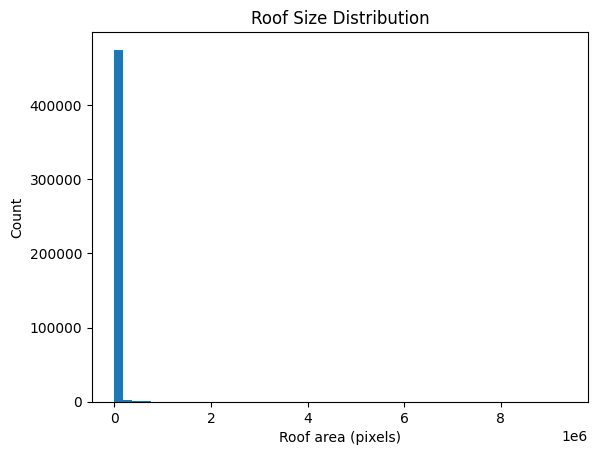

In [7]:
import cv2

areas = []

for mask_path in (base/"train/label").glob("*.tif"):
    with rasterio.open(mask_path) as src:
        mask = (src.read(1) > 0).astype("uint8")

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in contours:
        areas.append(cv2.contourArea(c))

import matplotlib.pyplot as plt
plt.hist(areas, bins=50)
plt.xlabel("Roof area (pixels)")
plt.ylabel("Count")
plt.title("Roof Size Distribution")
plt.show()


/tmp/ipykernel_17/2413029432.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(means, labels=["R", "G", "B"])


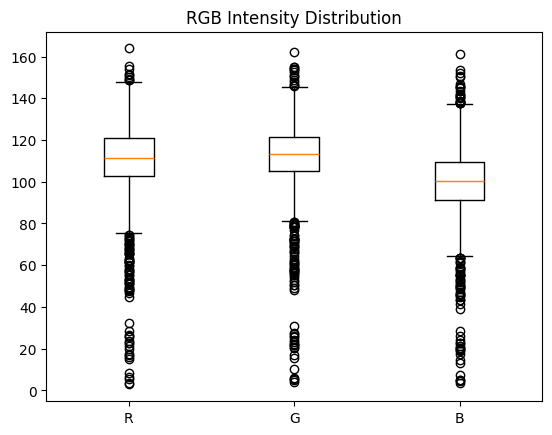

In [8]:
import numpy as np

means = []

for img_path in (base/"train/image").glob("*.tif"):
    with rasterio.open(img_path) as src:
        img = src.read([1,2,3])
    means.append(img.mean(axis=(1,2)))

means = np.array(means)

plt.boxplot(means, labels=["R", "G", "B"])
plt.title("RGB Intensity Distribution")
plt.show()


In [9]:
edges_ratio = []

for mask_path in (base/"train/label").glob("*.tif"):
    with rasterio.open(mask_path) as src:
        mask = (src.read(1) > 0).astype("uint8") * 255

    edges = cv2.Canny(mask, 50, 150)
    edges_ratio.append(edges.sum() / mask.sum())

print("Avg edge complexity:", np.mean(edges_ratio))


/tmp/ipykernel_17/3981622842.py:8: RuntimeWarning: invalid value encountered in scalar divide
  edges_ratio.append(edges.sum() / mask.sum())


Avg edge complexity: nan


In [10]:
def avg_roof(split):
    ratios = []
    for p in (base/split/"label").glob("*.tif"):
        with rasterio.open(p) as src:
            mask = src.read(1)
        ratios.append(roof_ratio(mask))
    return np.mean(ratios)

for s in ["train","val","test"]:
    print(s, avg_roof(s))


train 0.07692669296664449
val 0.0699900135474593
test 0.07249709936842105
